## Import Libraries for Differential Expression

#### z-scores: blue=low, white=mean, red=high.

In [398]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [399]:
from scipy.stats import ttest_ind

In [400]:
rng = np.random.default_rng(seed=42)

In [401]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import re


# Initialise Data Path

In [402]:
data_path = 'data/Raw_Data_Batch1_LAB2_CTX2.csv'
counts = pd.read_csv(data_path)
counts = counts.drop(columns=[
                   "Cellline ID", 
                   	"Row",
                    "Column",
                    "Timepoint",
                    "Field",
                    "Object No",
                    "X",
                    "Y",
                    "Bounding Box",
                    "Batch",
                    "Nuclei - Object No in Nuclei_all"
                   ])
# Double check here
print("counts (before): ", counts.shape)
counts = counts.dropna(axis=1)
print("counts (after): ", counts.shape)

# Isolate Controls
control_df = counts[counts['Cell Type'] == 'Control']
control_df['ID'] = range(0, control_df.shape[0])
control_df['Sample ID'] = control_df['Cell Type'] + ' ' + control_df['ID'].astype(str)


# Isolate LRRK2
lrrk2_df = counts[counts['Cell Type'] == 'LRRK2']
lrrk2_df['ID'] = range(0, lrrk2_df.shape[0])
lrrk2_df['Sample ID'] = lrrk2_df['Cell Type'] + ' ' + lrrk2_df['ID'].astype(str)

# Isolate PRKN
prkn_df = counts[counts['Cell Type'] == 'PRKN']
prkn_df['ID'] = range(0, prkn_df.shape[0])
prkn_df['Sample ID'] = prkn_df['Cell Type'] + ' ' + prkn_df['ID'].astype(str)

# Isolate SNCA
snca_df = counts[counts['Cell Type'] == 'SNCA']
snca_df['ID'] = range(0, snca_df.shape[0])
snca_df['Sample ID'] = snca_df['Cell Type'] + ' ' + snca_df['ID'].astype(str)

control_df = control_df.drop(columns=['Cell Type', 'ID'])
lrrk2_df = lrrk2_df.drop(columns=['Cell Type', 'ID'])
prkn_df = prkn_df.drop(columns=['Cell Type', 'ID'])
snca_df = snca_df.drop(columns=['Cell Type', 'ID'])


counts (before):  (53063, 681)
counts (after):  (53063, 404)


/tmp/ipykernel_252476/685310438.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  control_df['ID'] = range(0, control_df.shape[0])
/tmp/ipykernel_252476/685310438.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  control_df['Sample ID'] = control_df['Cell Type'] + ' ' + control_df['ID'].astype(str)
/tmp/ipykernel_252476/685310438.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using

In [ ]:
selected_controls = control_df.sample(n=50)
selected_lrrk2 = lrrk2_df.sample(n=50)
selected_prkn = prkn_df.sample(n=50)
selected_snca = snca_df.sample(n=50)

control_sample_ids = selected_controls['Sample ID']
lrrk2_sample_ids = selected_lrrk2['Sample ID']
prkn_sample_ids = selected_prkn['Sample ID']
snca_sample_ids = selected_snca['Sample ID']

In [404]:
# Control LRRK2 DataFrame
control_lrrk2_df = pd.concat([selected_controls, selected_lrrk2])
control_lrrk2_sample_ids = control_lrrk2_df['Sample ID']
control_lrrk2_df = control_lrrk2_df.drop(columns=['Sample ID'])
control_lrrk2_df = control_lrrk2_df.set_index(control_lrrk2_sample_ids)
control_lrrk2_df = np.arcsinh(control_lrrk2_df)


# Control PRKN DataFrame
control_prkn_df = pd.concat([selected_controls, selected_prkn])
control_prkn_sample_ids = control_prkn_df['Sample ID']
control_prkn_df = control_prkn_df.drop(columns=['Sample ID'])
control_prkn_df = control_prkn_df.set_index(control_prkn_sample_ids)
control_prkn_df = np.arcsinh(control_prkn_df)


# Control SNCA DataFrame
control_snca_df = pd.concat([selected_controls, selected_snca])
control_snca_sample_ids = control_snca_df['Sample ID']
control_snca_df = control_snca_df.drop(columns=['Sample ID'])
control_snca_df = control_snca_df.set_index(control_snca_sample_ids)
control_snca_df = np.arcsinh(control_snca_df)

# We want each feature to be a column and the samples should be the rows

In [405]:
## We already have that :)
control_lrrk2_df.head()

,Position X [Âµm],Position Y [Âµm],Mitochondria Intensity - Nucleus region Mean,Mitochondria Intensity - Nucleus region StdDev,Mitochondria Intensity - Nucleus region Median,Mitochondria Intensity - Nucleus region Maximum,Mitochondria Intensity - Nucleus region Minimum,Mitochondria Intensity - Nucleus region Sum,Mitochondria Intensity - Nucleus region CV [%],Mitochondria Intensity - Nucleus region Quantile 90%,...,General Dimension - Outer region Width µm,General Dimension - Outer region Length µm,Mitochondria Spatial - Outer region Profile 4/5 SER-Dark,Mitochondria Spatial - Outer region Profile 5/5 SER-Dark,Mitochondria Spatial - Outer region Profile 4/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 5/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 4/5 SER-Spot,Mitochondria Spatial - Outer region Profile 5/5 SER-Spot,Mitochondria Spatial - Outer region Profile 4/5 SER-Edge,Mitochondria Spatial - Outer region Profile 5/5 SER-Edge
Sample ID,,,,,,,,,,,,,,,,,,,,,
Control 5163,-7.395317,-5.373354,7.509200,6.325218,7.450080,8.256867,6.775367,12.615145,4.114600,7.883823,...,2.105346,4.019484,0.040253,0.030712,0.015818,0.014016,0.019481,0.013883,0.116983,0.083330
Control 3385,7.116070,-7.492504,8.630050,8.447852,8.132707,9.897671,6.871092,13.882324,5.116154,9.451717,...,2.773984,4.931748,0.056657,0.073879,0.025221,0.011272,0.009198,0.004462,0.263435,0.242881
Control 22388,-7.950672,-5.331969,6.878879,5.289036,6.858566,7.351159,6.406883,12.615450,3.709052,7.122867,...,1.155182,3.906848,0.040584,0.035143,0.008081,0.011220,0.003089,0.005144,0.074918,0.061722
Control 21022,-6.597366,-7.302497,6.698464,6.097045,6.461471,7.941651,6.095830,12.533273,4.696977,7.109880,...,1.155182,3.850481,0.037870,0.039076,0.012743,0.006543,0.004525,0.005911,0.119506,0.076044
Control 3468,7.872402,-7.053154,6.805504,5.858513,6.664411,8.005701,6.452051,12.482256,4.351484,7.121253,...,2.641501,4.740721,0.028674,0.033216,0.019763,0.009346,0.017378,0.005654,0.076356,0.062663


# Make a MetaData Dataframe

In [406]:
conditions_list = []

for i in control_sample_ids:
    conditions_list.append('C')

for i in lrrk2_sample_ids:
    conditions_list.append('L')

In [407]:
metadata = pd.DataFrame(
    zip(control_lrrk2_df.index, conditions_list), columns=['Sample', 'Condition']
)
metadata = metadata.set_index('Sample')
metadata.tail()

,Condition
Sample,
LRRK2 4323,L
LRRK2 2733,L
LRRK2 3989,L
LRRK2 6106,L
LRRK2 5376,L


## Control vs LRRK2

Found 13 differentially expressed columns


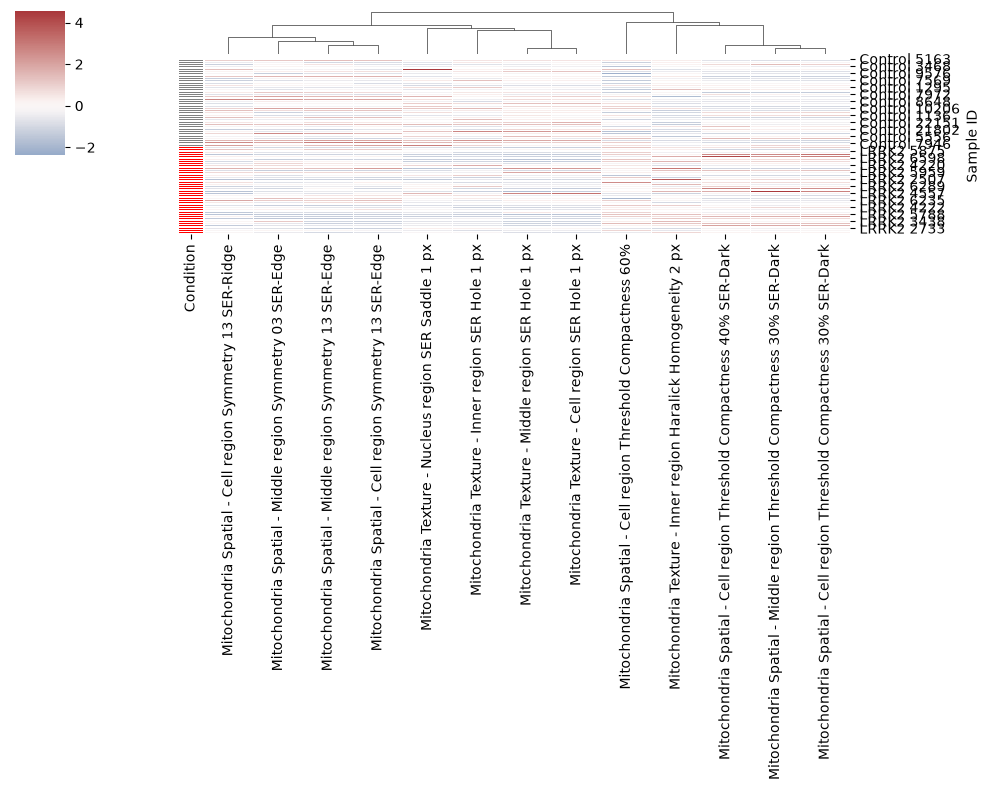

In [408]:
# Initialise an empty list for significant columns
significant_cols = []

# Check Data type here, we only want the numeric columns
numeric_cols = control_lrrk2_df.select_dtypes(include='number')

# Go over the columns
for col in numeric_cols:
    stat, p_val = ttest_ind(selected_controls[col], selected_lrrk2[col])
    
    # Check if p_val is less than 0.001
    if p_val < 0.005: 
        significant_cols.append(col)

print(f"Found {len(significant_cols)} differentially expressed columns")

# 3. Prepare the matrix for the Heatmap
# Select only significant columns
heatmap_data = control_lrrk2_df[significant_cols]

# Optional but highly recommended: Create a color sidebar to track the groups
group_labels = metadata['Condition']
lut = {'C': 'grey', 'L': 'Red'}
row_colors = group_labels.map(lut)

# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,  # Colors the rows by group identity
    cmap='vlag',         
    center=0,               # Centers the colorbar at 0
    linewidths=0.5,
    figsize=(10, 8),
    col_cluster=True,
    row_cluster=False,
    z_score=1
)

Found 13 differentially expressed columns


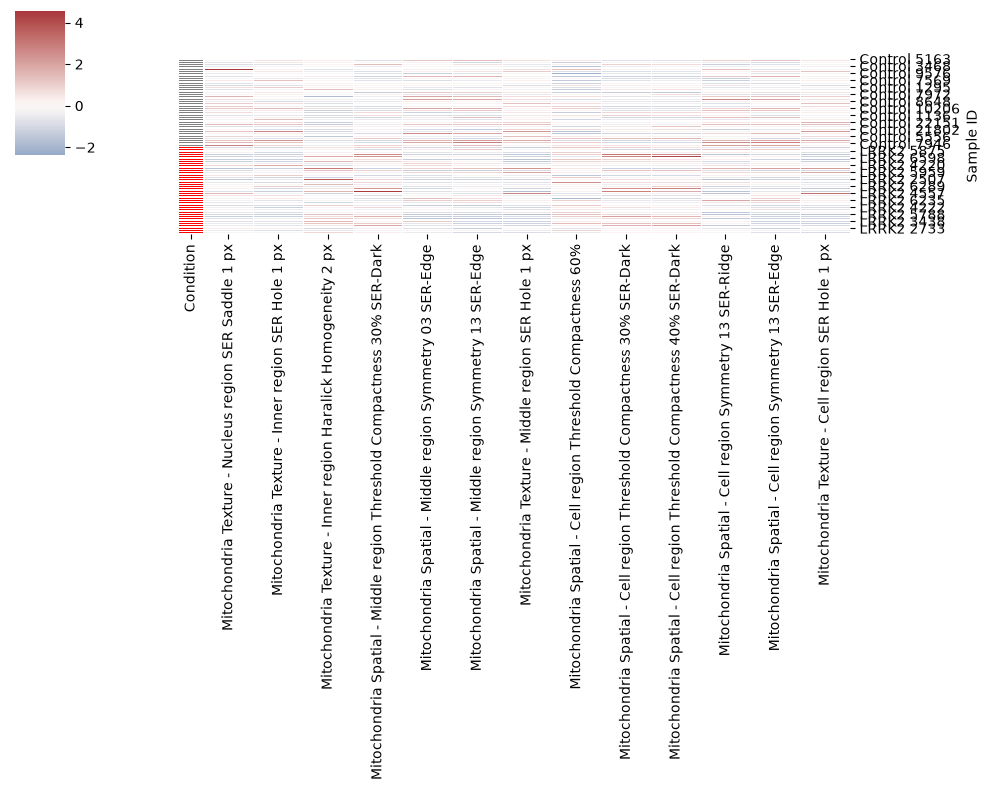

In [409]:
# Initialise an empty list for significant columns
significant_cols = []

# Check Data type here, we only want the numeric columns
numeric_cols = control_lrrk2_df.select_dtypes(include='number')

# Go over the columns
for col in numeric_cols:
    stat, p_val = ttest_ind(selected_controls[col], selected_lrrk2[col])
    
    # Check if p_val is less than 0.001
    if p_val < 0.005: 
        significant_cols.append(col)

print(f"Found {len(significant_cols)} differentially expressed columns")

# 3. Prepare the matrix for the Heatmap
# Select only significant columns
heatmap_data = control_lrrk2_df[significant_cols]

# Optional but highly recommended: Create a color sidebar to track the groups
group_labels = metadata['Condition']
lut = {'C': 'grey', 'L': 'Red'}
row_colors = group_labels.map(lut)

# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,  # Colors the rows by group identity
    cmap='vlag',         
    center=0,               # Centers the colorbar at 0
    linewidths=0.5,
    figsize=(10, 8),
    col_cluster=False,
    row_cluster=False,
    z_score=1
)

# Make a MetaData Dataframe

In [410]:
conditions_list = []

for i in control_sample_ids:
    conditions_list.append('C')

for i in prkn_sample_ids:
    conditions_list.append('P')

In [411]:
metadata = pd.DataFrame(
    zip(control_prkn_df.index, conditions_list), columns=['Sample', 'Condition']
)
metadata = metadata.set_index('Sample')
metadata.tail()

,Condition
Sample,
PRKN 5090,P
PRKN 5799,P
PRKN 2000,P
PRKN 5552,P
PRKN 5101,P


## Control vs PRKN

Found 53 differentially expressed columns


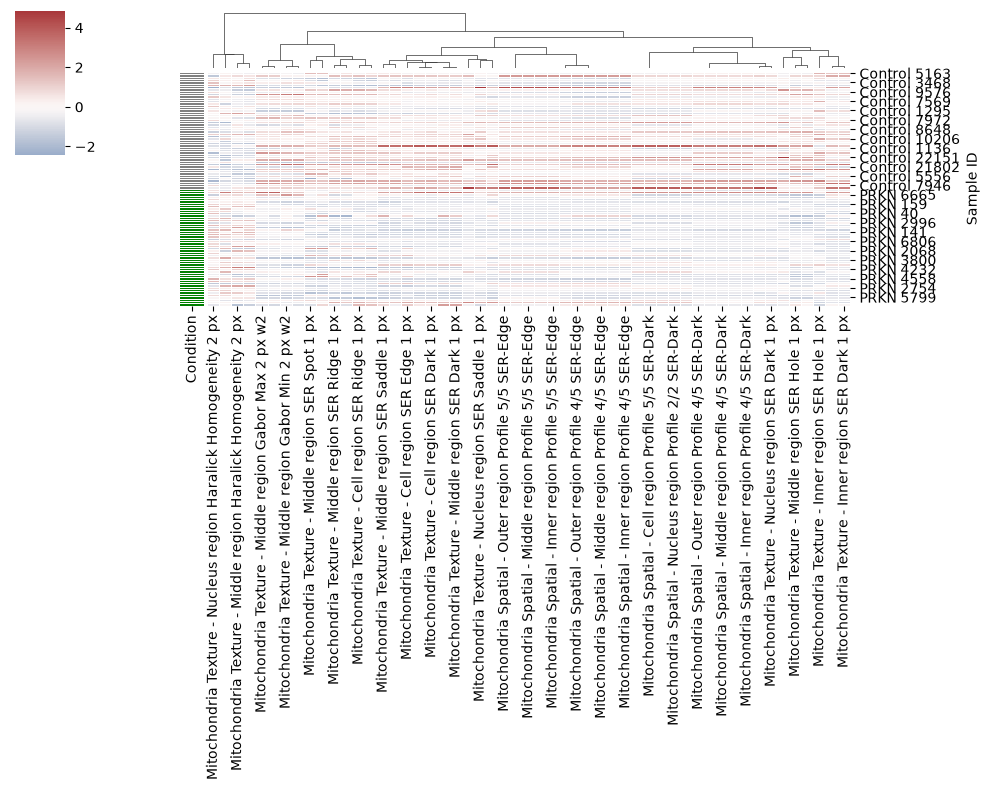

In [412]:
# Initialise an empty list for significant columns
significant_cols = []

# Check Data type here, we only want the numeric columns
numeric_cols = control_prkn_df.select_dtypes(include='number')

# Go over the columns
for col in numeric_cols:
    stat, p_val = ttest_ind(selected_controls[col], selected_prkn[col])
    
    # Check if p_val is less than 0.001
    if p_val < 0.005: 
        significant_cols.append(col)

print(f"Found {len(significant_cols)} differentially expressed columns")

# 3. Prepare the matrix for the Heatmap
# Select only significant columns
heatmap_data = control_prkn_df[significant_cols]

# Optional but highly recommended: Create a color sidebar to track the groups
group_labels = metadata['Condition']
lut = {'C': 'grey', 'P': 'Green'}
row_colors = group_labels.map(lut)

# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,  # Colors the rows by group identity
    cmap='vlag', 
    metric="euclidean",
    method="ward",      
    center=0,               # Centers the colorbar at 0
    linewidths=0.5,
    figsize=(10, 8),
    col_cluster=True,
    row_cluster=False,
    z_score=1
)

Found 53 differentially expressed columns


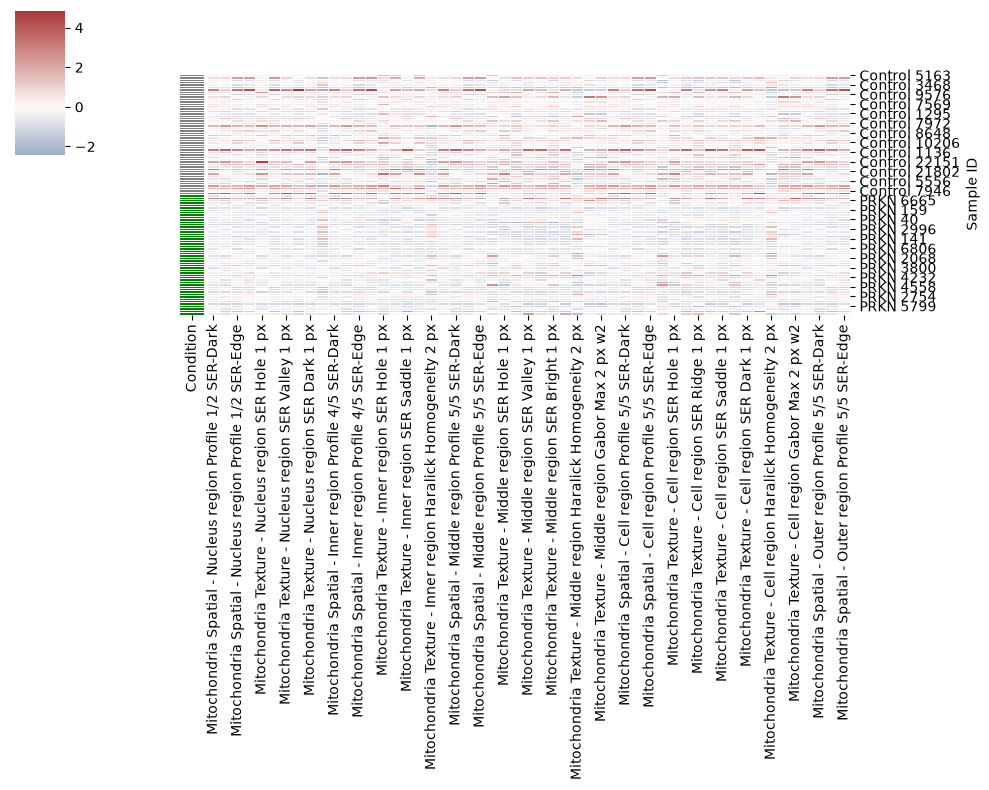

In [413]:
# Initialise an empty list for significant columns
significant_cols = []

# Check Data type here, we only want the numeric columns
numeric_cols = control_prkn_df.select_dtypes(include='number')

# Go over the columns
for col in numeric_cols:
    stat, p_val = ttest_ind(selected_controls[col], selected_prkn[col])
    
    # Check if p_val is less than 0.001
    if p_val < 0.005: 
        significant_cols.append(col)

print(f"Found {len(significant_cols)} differentially expressed columns")

# 3. Prepare the matrix for the Heatmap
# Select only significant columns
heatmap_data = control_prkn_df[significant_cols]

# Optional but highly recommended: Create a color sidebar to track the groups
group_labels = metadata['Condition']
lut = {'C': 'grey', 'P': 'Green'}
row_colors = group_labels.map(lut)

# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,  # Colors the rows by group identity
    cmap='vlag',         
    center=0,               # Centers the colorbar at 0
    linewidths=0.5,
    figsize=(10, 8),
    col_cluster=False,
    row_cluster=False,
    z_score=1,
    metric="euclidean",
    method="ward"
)

In [414]:
X = control_prkn_df[significant_cols]
init_y = list(control_lrrk2_sample_ids)
y = []
for i in init_y:
    y.append(re.split(r"(\d+)", i)[0].strip())
    # print(y)


In [415]:
print(y)

['Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'Control', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK', 'LRRK']


In [416]:
pca = PCA(n_components=4)
x_pca = pca.fit_transform(X)

0     Control
1     Control
2     Control
3     Control
4     Control
       ...   
95       LRRK
96       LRRK
97       LRRK
98       LRRK
99       LRRK
Name: Genotype, Length: 100, dtype: str

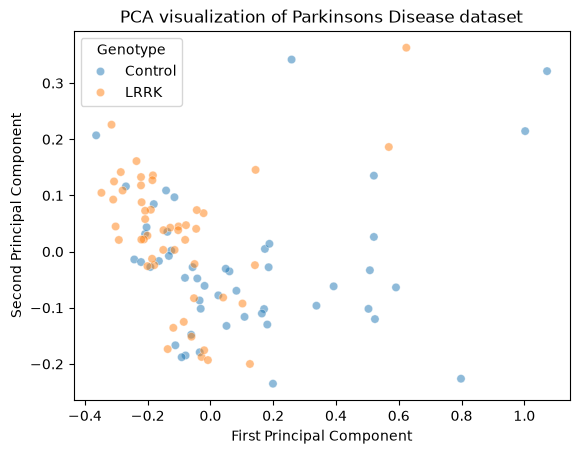

In [417]:
# fig = pyplot.scatter(x=x_pca[:, 0], y=x_pca[:, 1], color=y)

full_df = pd.DataFrame(data=x_pca, columns=['Principal Component 1', 'Principal Component 2','Principal Component 3', 'Principal Component 4'])
full_df['Genotype'] = y
# fig = px.scatter(x=x_pca[:, 0], y=x_pca[:, 1], color=y)
# full_df.head()
fig = sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Genotype',
    data=full_df,
    alpha=0.5
)


fig.set_title('PCA visualization of Parkinson''s Disease dataset')

fig.set_xlabel('First Principal Component')
fig.set_ylabel('Second Principal Component')
full_df['Genotype']

# Make a MetaData Dataframe

In [418]:
conditions_list = []

for i in control_sample_ids:
    conditions_list.append('C')

for i in snca_sample_ids:
    conditions_list.append('S')

In [419]:
metadata = pd.DataFrame(
    zip(control_snca_df.index, conditions_list), columns=['Sample', 'Condition']
)
metadata = metadata.set_index('Sample')
metadata.tail()

,Condition
Sample,
SNCA 8873,S
SNCA 11698,S
SNCA 451,S
SNCA 2519,S
SNCA 9159,S


## Control vs SNCA

Found 3 differentially expressed columns


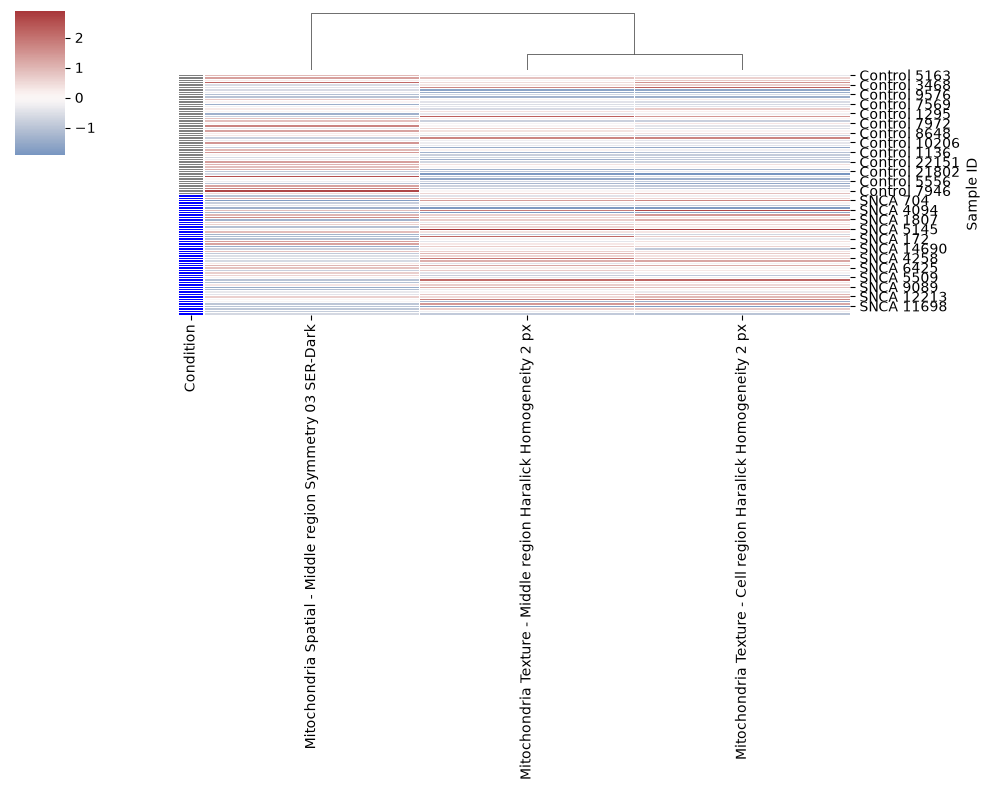

In [420]:
# Initialise an empty list for significant columns
significant_cols = []

# Check Data type here, we only want the numeric columns
numeric_cols = control_snca_df.select_dtypes(include='number')

# Go over the columns
for col in numeric_cols:
    stat, p_val = ttest_ind(selected_controls[col], selected_snca[col])
    
    # Check if p_val is less than 0.001
    if p_val < 0.005: 
        significant_cols.append(col)

print(f"Found {len(significant_cols)} differentially expressed columns")

# Prepare the matrix for the Heatmap
# Select only significant columns
heatmap_data = control_snca_df[significant_cols]

# Optional but highly recommended: Create a color sidebar to track the groups
group_labels = metadata['Condition']
lut = {'C': 'grey', 'S': 'Blue'}
row_colors = group_labels.map(lut)

# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,  # Colors the rows by group identity
    cmap='vlag',         
    center=0,               # Centers the colorbar at 0
    linewidths=0.5,
    figsize=(10, 8),
    z_score=1,
    col_cluster=True,
    row_cluster=False
)

Found 3 differentially expressed columns


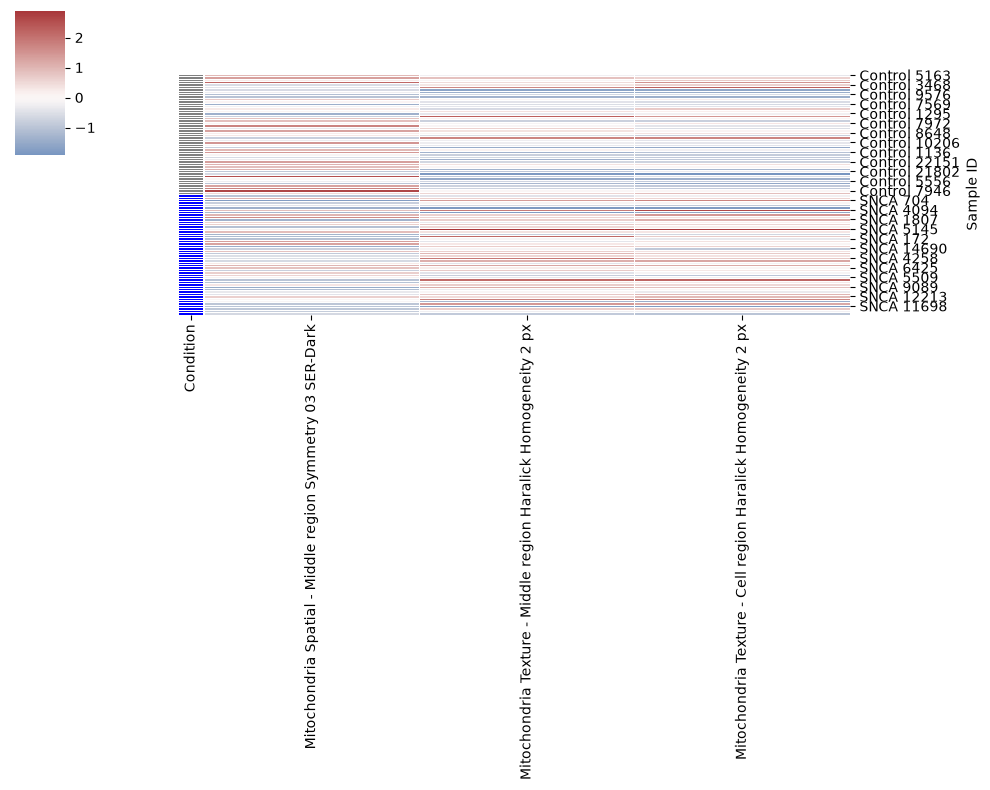

In [421]:
# Initialise an empty list for significant columns
significant_cols = []

# Check Data type here, we only want the numeric columns
numeric_cols = control_snca_df.select_dtypes(include='number')

# Go over the columns
for col in numeric_cols:
    stat, p_val = ttest_ind(selected_controls[col], selected_snca[col])
    
    # Check if p_val is less than 0.001
    if p_val < 0.005: 
        significant_cols.append(col)

print(f"Found {len(significant_cols)} differentially expressed columns")

# Prepare the matrix for the Heatmap
# Select only significant columns
heatmap_data = control_snca_df[significant_cols]

# Optional but highly recommended: Create a color sidebar to track the groups
group_labels = metadata['Condition']
lut = {'C': 'grey', 'S': 'Blue'}
row_colors = group_labels.map(lut)

# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,  # Colors the rows by group identity
    cmap='vlag',         
    center=0,               # Centers the colorbar at 0
    linewidths=0.5,
    figsize=(10, 8),
    z_score=1,
    col_cluster=False,
    row_cluster=False
)

# Make a MetaData Dataframe

In [422]:
conditions_list = []

for i in control_sample_ids:
    conditions_list.append('C')

for i in prkn_sample_ids:
    conditions_list.append('P')

In [423]:
metadata = pd.DataFrame(
    zip(control_prkn_df.index, conditions_list), columns=['Sample', 'Condition']
)
metadata = metadata.set_index('Sample')
metadata.tail()

,Condition
Sample,
PRKN 5090,P
PRKN 5799,P
PRKN 2000,P
PRKN 5552,P
PRKN 5101,P


## Control vs PRKN

Found 39 differentially expressed columns


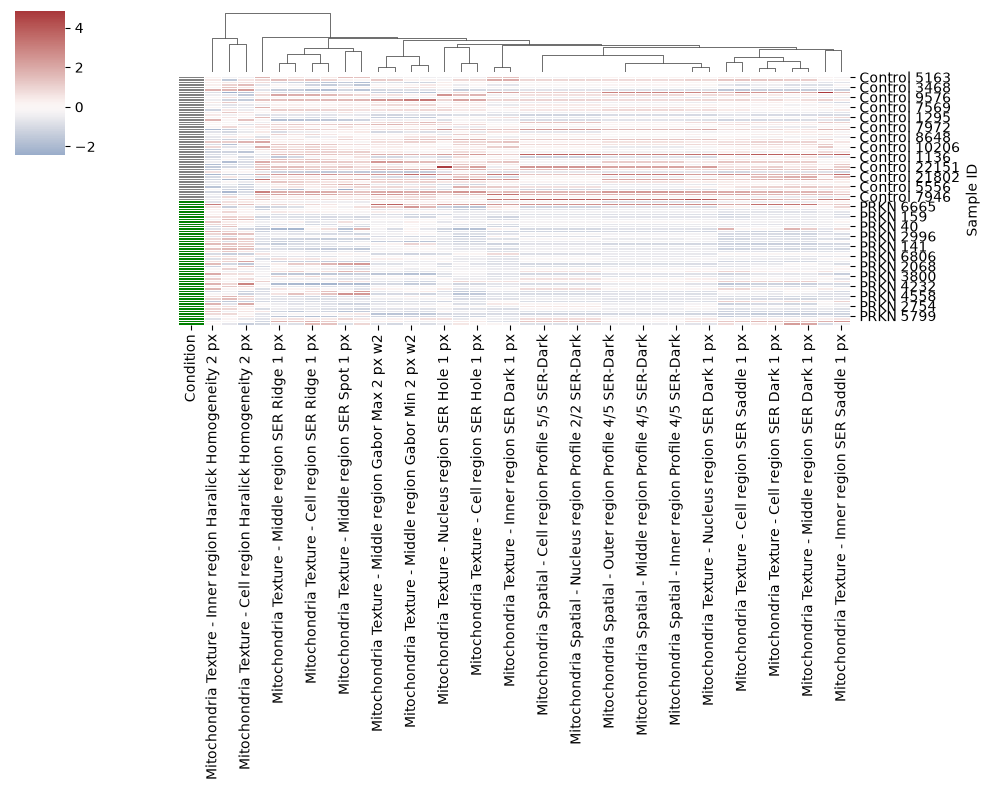

In [424]:
# Initialise an empty list for significant columns
significant_cols = []

# Check Data type here, we only want the numeric columns
numeric_cols = control_prkn_df.select_dtypes(include='number')

# Go over the columns
for col in numeric_cols:
    stat, p_val = ttest_ind(selected_controls[col], selected_prkn[col])
    
    # Check if p_val is less than 0.001
    if p_val < 0.001: 
        significant_cols.append(col)

print(f"Found {len(significant_cols)} differentially expressed columns")

# 3. Prepare the matrix for the Heatmap
# Select only significant columns
heatmap_data = control_prkn_df[significant_cols]

# Optional but highly recommended: Create a color sidebar to track the groups
group_labels = metadata['Condition']
lut = {'C': 'grey', 'P': 'Green'}
row_colors = group_labels.map(lut)

# 4. Plot the Clustered Heatmap
g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,  # Colors the rows by group identity
    cmap='vlag',         
    center=0,               # Centers the colorbar at 0
    linewidths=0.5,
    figsize=(10, 8),
    col_cluster=True,
    row_cluster=False,
    z_score=1
)

## Try to Rank the most important features as well

## Classification-tree in scikit learn

In [425]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [426]:
annotated_control_df = control_df
annotated_control_df['Cell Type'] = 'Control'
# annotated_control_df.head()

annotated_lrrk2_df = lrrk2_df
annotated_lrrk2_df['Cell Type'] = 'LRRK2'
# annotated_lrrk2_df.head()

annotated_lrrk2_control_df = pd.concat([annotated_control_df, annotated_lrrk2_df])
annotated_lrrk2_control_df = annotated_lrrk2_control_df.drop(columns=['Sample ID'])
annotated_lrrk2_control_df.tail()

/tmp/ipykernel_252476/1895858568.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  annotated_control_df['Cell Type'] = 'Control'
/tmp/ipykernel_252476/1895858568.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  annotated_lrrk2_df['Cell Type'] = 'LRRK2'


,Position X [Âµm],Position Y [Âµm],Mitochondria Intensity - Nucleus region Mean,Mitochondria Intensity - Nucleus region StdDev,Mitochondria Intensity - Nucleus region Median,Mitochondria Intensity - Nucleus region Maximum,Mitochondria Intensity - Nucleus region Minimum,Mitochondria Intensity - Nucleus region Sum,Mitochondria Intensity - Nucleus region CV [%],Mitochondria Intensity - Nucleus region Quantile 90%,...,General Dimension - Outer region Length µm,Mitochondria Spatial - Outer region Profile 4/5 SER-Dark,Mitochondria Spatial - Outer region Profile 5/5 SER-Dark,Mitochondria Spatial - Outer region Profile 4/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 5/5 SER-Ridge,Mitochondria Spatial - Outer region Profile 4/5 SER-Spot,Mitochondria Spatial - Outer region Profile 5/5 SER-Spot,Mitochondria Spatial - Outer region Profile 4/5 SER-Edge,Mitochondria Spatial - Outer region Profile 5/5 SER-Edge,Cell Type
41460,992.93,-911.29,536.359,313.843,424,2012,310,167344,58.5136,828,...,26.3937,0.023066,0.046485,0.028896,0.006959,0.018929,0.004254,0.111617,0.084560,LRRK2
41461,1249.95,-910.35,489.030,151.443,429,1310,354,180941,30.9681,689,...,46.9807,0.023506,0.027946,0.019347,0.006548,0.009394,0.003327,0.088638,0.049475,LRRK2
41462,1133.17,-923.46,1509.450,1276.250,1041,7069,459,307928,84.5509,3334,...,98.3979,0.036024,0.046499,0.025821,0.014341,0.019974,0.005337,0.203615,0.164448,LRRK2
41463,1227.68,-946.62,1121.830,213.340,1122,1479,674,99843,19.0171,1391,...,40.4293,0.008614,0.000442,0.026763,0.023848,0.021153,0.034322,0.130311,0.079928,LRRK2
41464,1210.35,-946.95,715.559,346.510,604,1956,374,194632,48.4251,1255,...,17.1780,0.017715,0.044615,0.029861,0.012029,0.013897,0.007554,0.102515,0.106824,LRRK2


In [427]:
X = annotated_lrrk2_control_df.drop(columns=['Cell Type'])
y = annotated_lrrk2_control_df['Cell Type']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=1
)

In [428]:
pd_classifier = DecisionTreeClassifier(max_depth=3, random_state=1)

In [429]:
pd_classifier.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

In [430]:
y_pred = pd_classifier.predict(X_test)

In [431]:
accuracy_score(y_test, y_pred)

0.8046396023198011

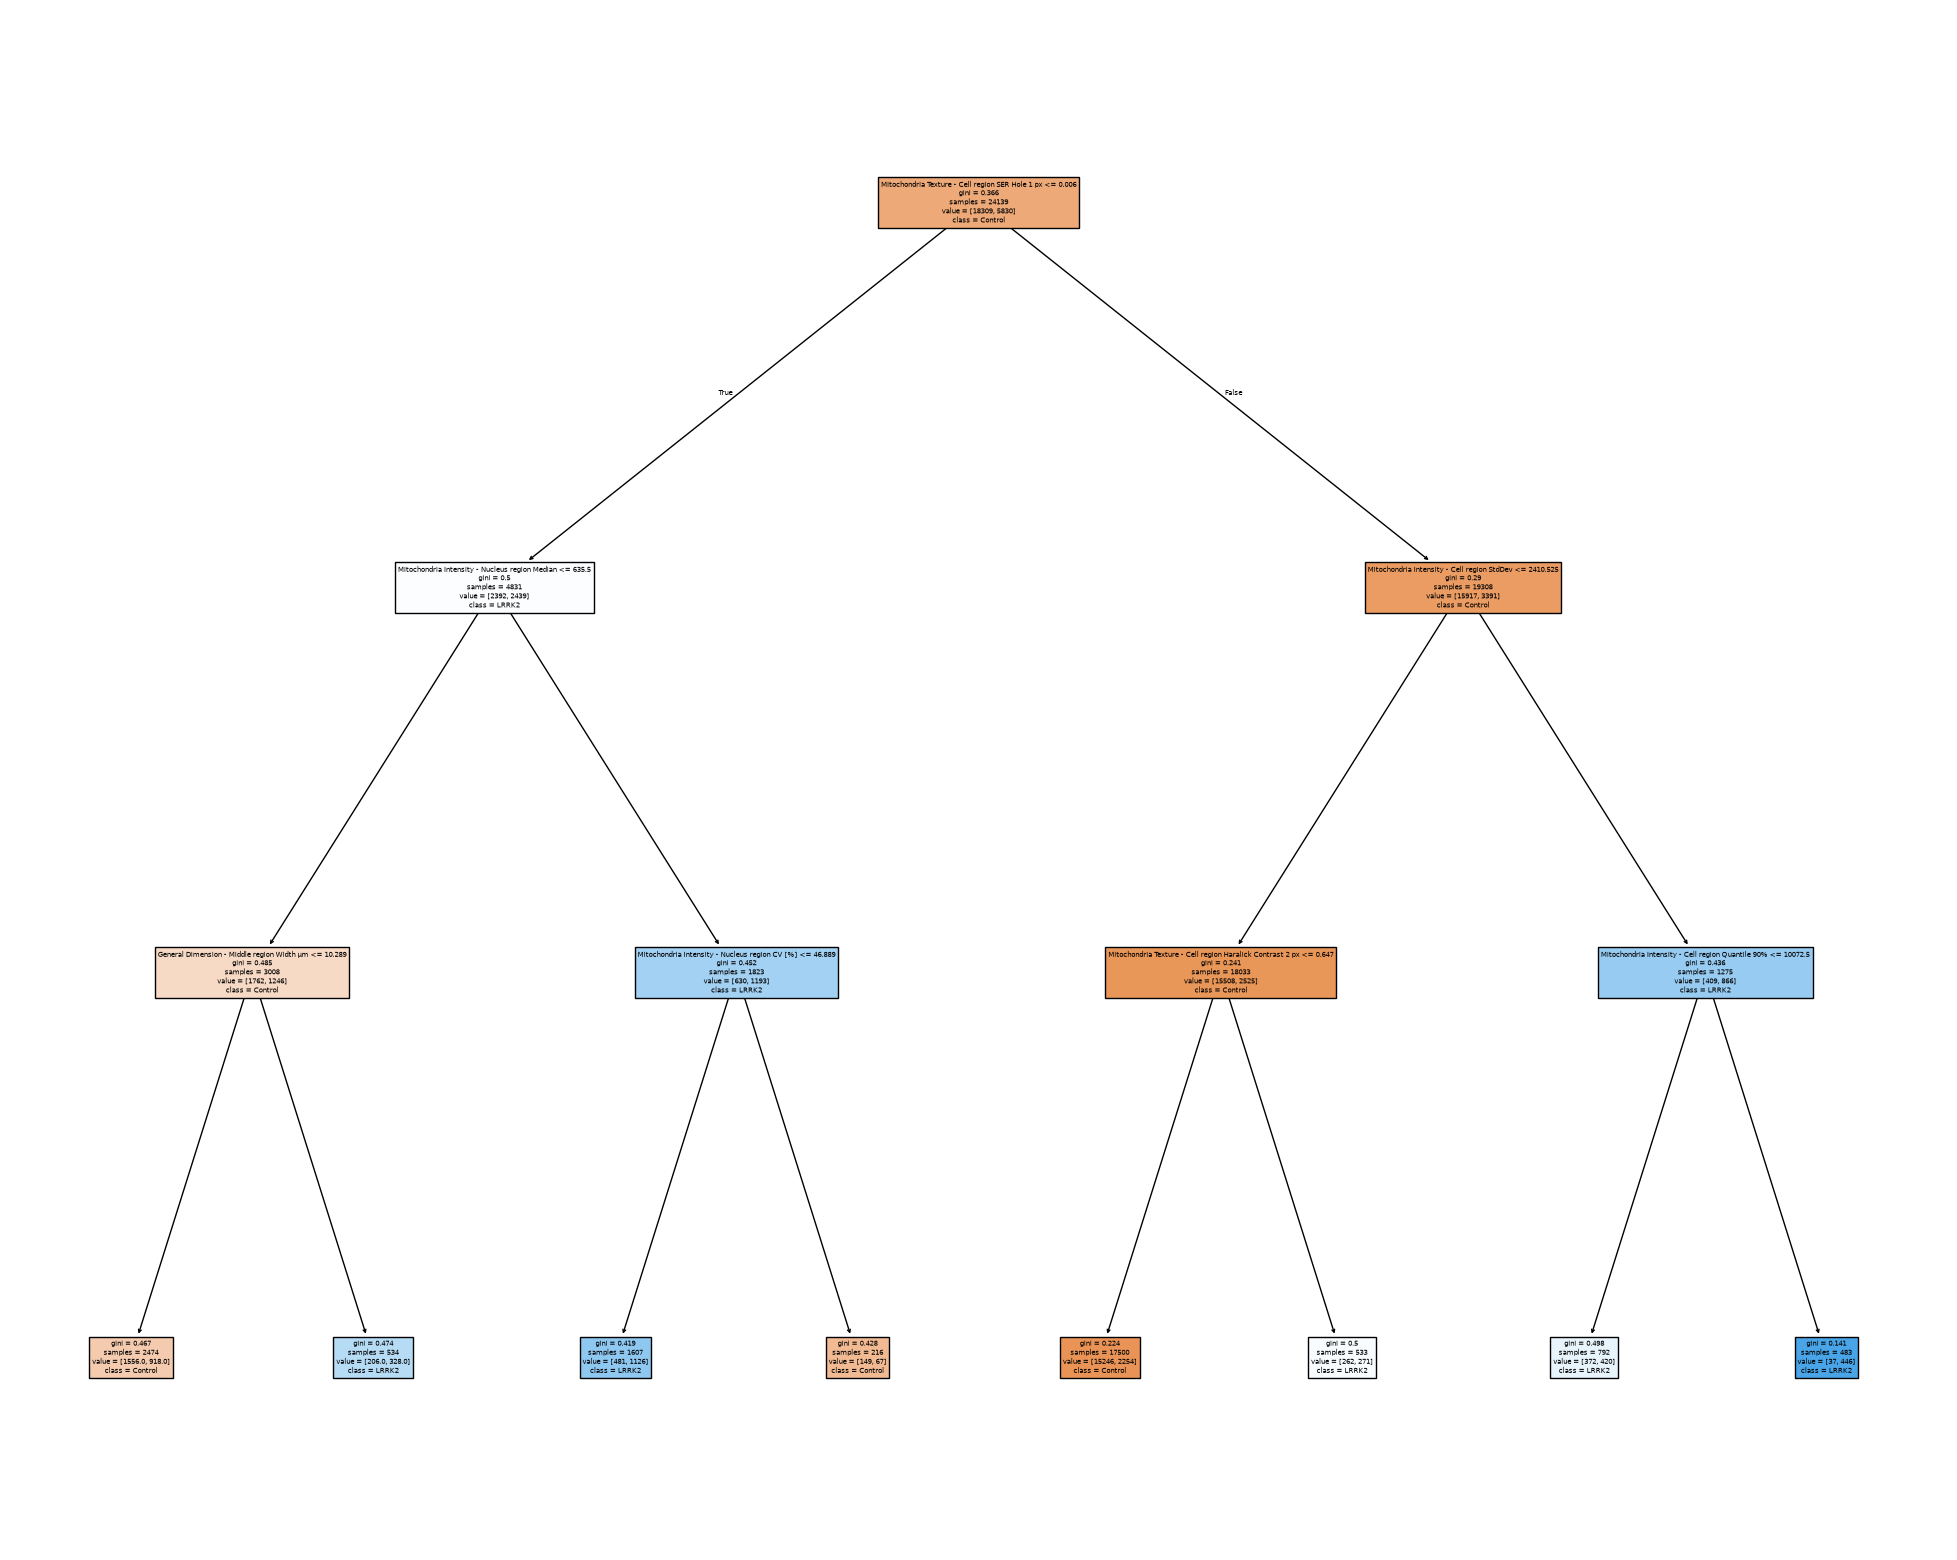

In [432]:
fig = plt.figure(figsize=(25,20))
_ = plot_tree(pd_classifier,
                   feature_names=X_test.columns,
                   class_names=['Control', 'LRRK2'],
                   filled=True)

In [433]:
# Decision Regions